Computational Note: Execution Time

Algorithm: Second-order-Stochastic Dominance with CVaR formulation.

Complexity: O(T^2) variables per optimization (250^2 = 62,500 variables).

Estimated Runtime: ~4-7 hours using the SciPy HiGHS solver.

In [ ]:
import pandas as pd
import numpy as np
import time
import statsmodels.api as sm
from scipy.optimize import linprog
from scipy import sparse
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file = "/content/drive/MyDrive/Colab Notebooks/OPTIMIZATION/Datisp100agg.xlsx"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#file = r"C:\Users\stefa\OneDrive\Documents\Master\TESI\MATLAB\Datisp100agg.xlsx"

In [ ]:
# Read all sheets without assuming headers and sheet name --> creates a dict where keys: title , values : dataframes
sheets = pd.read_excel(file, sheet_name=None, header=None)
print(sheets.keys())

dict_keys(['df_ret_final', 'composition', 'ISIN', 'Date', 'nomi', 'Index'])


In [ ]:
returns = sheets["df_ret_final"]
composition = sheets["composition"]
Dates = sheets['Date']
nomi = sheets["nomi"]
sp100 = sheets["Index"]

In [ ]:
# prepare returns dataset
Index = Dates.iloc[:, 0]    # select first column
returns.index = pd.to_datetime(Index)   # set date as index
composition.index = pd.to_datetime(Index)

# add suffixes
stocks_name = nomi.iloc[0, :].tolist()   # retrieve names
returns.columns = stocks_name
composition.columns = stocks_name
returns.index.name = "Date"
composition.index.name = "Date"

In [ ]:
# prepare benchamrk dataset
benchmark = sp100
benchmark = benchmark.fillna(0)    # daily returns
benchmark.index = pd.to_datetime(Index)   # set same dates as returns df
benchmark.columns = ["sp100"]
benchmark.index.name = "Date"

In [ ]:
# Check for duplicates in the original dataset columns and delete them
dup_mask = returns.columns.duplicated()   # duplicates mask

if dup_mask.any():
    print(f"Found duplicate asset names: {returns.columns[dup_mask].tolist()}")
    returns = returns.loc[:, ~dup_mask]    # remove them
    composition = composition.loc[:, ~composition.columns.duplicated()]    # remove also from comp matrix
else:
    print("No duplicates found")

Found duplicate asset names: ['Alphabet Inc', 'Comcast Corp', 'TFCF Corp']


In [ ]:
# function to see asset name and dominance type
def view_dominated_asset(rebalancing_date, target_name, dominance_type):
    print(f""""Rebalancing date: {rebalancing_date}
        Dominated asset: {target_name}
        Dominance type: {dominance_type}""")

In [ ]:
def sd_test_vect(asset_ret, bench_ret):
    """Vectorized SD test. ~100x faster than looping."""
    assets = asset_ret.to_numpy()
    bench = bench_ret.to_numpy().flatten()

    # Sort columns independently
    sorted_assets = np.sort(assets, axis=0)
    sorted_bench = np.sort(bench)

    # Broadcast subtraction: (T, K) - (T, 1)
    diff = sorted_bench[:, None] - sorted_assets

    # Masks for dominance
    # Note: Logic assumes Bench dominates if Bench >= Asset (diff <= 0) strictly
    # 1. FSD: All diff < 0
    fsd_mask = np.all(diff > 0, axis=0) & np.any(diff > 0, axis = 0)

    # 2. SSD: Cumsum > 0 (and not FSD)
    cum_diff = np.cumsum(diff, axis=0)
    ssd_mask = np.all(cum_diff >= 0, axis=0) & (~fsd_mask)

    # 3. TSD: Cumsum of Cumsum < 0 (and not FSD/SSD)
    cum_cum = np.cumsum(cum_diff, axis=0)
    tsd_mask = np.all(cum_cum >= 0, axis=0) & (~fsd_mask) & (~ssd_mask)

    # Priority: FSD(1) > SSD(2) > TSD(3)
    dom_status = np.zeros(assets.shape[1], dtype=int)
    dom_status[fsd_mask] = 1
    dom_status[ssd_mask] = 2
    dom_status[tsd_mask] = 3

    dominated_indices = np.where(dom_status > 0)[0]

    if len(dominated_indices) > 0:
        # Pick asset with lowest mean among dominated
        means = np.mean(assets[:, dominated_indices], axis=0)
        local_idx = np.argmin(means)     # worst mean index
        worst_5_idx = np.argsort(means)[:4]    # worst 4 mean index
        global_idx = dominated_indices[local_idx]
        global_5 = dominated_indices[worst_5_idx]
        dom_list = asset_ret.columns[dominated_indices]    #list of dominated assets

        type_map = {1: "fsd", 2: "ssd", 3: "tsd"}

        return asset_ret.iloc[:, global_idx], asset_ret.columns[global_idx], type_map[dom_status[global_idx]], dom_list, asset_ret.columns[global_5]
    else:
        return bench_ret, "sp100", "No SD"

In [ ]:
# calculate CVaR --> Probability != 1/T  (EL or other)
def calculate_cvar_limit_el(returns, probability, alpha):
    losses = -returns
    # Sort losses descending (worst first)
    sort_idx = np.argsort(losses)[::-1]
    sorted_losses = losses[sort_idx]
    sorted_probs = probability[sort_idx]

    cum_probs = np.cumsum(sorted_probs)

    # Find the exact index where cumulative probability hits alpha
    cutoff_idx = np.searchsorted(cum_probs, alpha)

    if cutoff_idx == 0:
        return sorted_losses[0]

    # Calculate expected shortfall under EL weights
    tail_losses = sorted_losses[:cutoff_idx]
    tail_probs = sorted_probs[:cutoff_idx]

    # Add the fractional part of the boundary scenario to perfectly match alpha
    fractional_prob = alpha - cum_probs[cutoff_idx - 1]

    cvar = (np.sum(tail_losses * tail_probs) + sorted_losses[cutoff_idx] * fractional_prob) / alpha
    return cvar

In [ ]:
def optimize_ssd_el(X, y, p=None):
    """
    Optimizes a portfolio using Stochastic Dominance and Empirical Likelihood (Post 2017).

    X: numpy array (N, K) - historical returns of K base assets over N days
    y: numpy array (N,) - historical returns of the index benchmark
    p: numpy array (N,) - EL state probabilities. Defaults to 1/N if None.
    """
    # convert to numpy array before to avoid pandas error
    X = np.array(X)
    y = np.array(y).flatten()

    N, K = X.shape

    # Default to equal probabilities if EL is not provided
    if p is None:
        p = np.ones(N) / N

    # 1. Pre-calculate the exact historical LPM of the Index for all thresholds y_s
    # L_tau[s] = sum_t { p_t * max(0, y_s - y_t) }

    # use broadcasting to calculate without loops
    diff_matrix = np.maximum(0, y[:, None] - y[None, :])
    L_tau = diff_matrix @ p

    # Total Variables: K (weights) + N^2 (Theta dummies for every s, t pair)
    num_vars = K + N**2

    # -----------------------------------------------
    # 2. Objective Function: Maximize expected return under EL (Minimize negative return)
    # Expected return = sum(p_t * X_t)
    c = np.zeros(num_vars)
    c[:K] = -(p @ X)

    # ----------------------------------------------
    # 3. Equality Constraint: sum(weights) == 1
    A_eq = sparse.lil_matrix((1, num_vars))
    A_eq[0, :K] = 1
    b_eq = np.array([1.0])

    # -------------------------------------------------
    # 4. Inequality Constraints (A_ub @ x <= b_ub)


    # --- Set 1: LPM Dominance Constraints (N rows) ---
    # Equation: sum_t(p_t * Theta_{s,t}) <= L_tau(y_s) for all s

    row_1 = np.repeat(np.arange(N), N)
    col_1 = K + np.arange(N**2)
    data_1 = np.tile(p, N)  # The probabilities p_t are the coefficients here

    A_ub_1 = sparse.csr_matrix((data_1, (row_1, col_1)), shape=(N, num_vars))
    b_ub_1 = L_tau

    # --- Set 2: Theta Dummy Constraints (N^2 rows) ---
    # Equation: -Theta_{s,t} - X_t * w <= -y_s
    # A given row `r = s * N + t` corresponds to threshold y_s, day t.

    # Weight components (-X_t)
    row_2_w = np.repeat(np.arange(N**2), K)
    col_2_w = np.tile(np.arange(K), N**2)
    data_2_w = np.tile(-X, (N, 1)).flatten()

    # Theta components (-1 for Theta_{s,t})
    row_2_theta = np.arange(N**2)
    col_2_theta = K + np.arange(N**2)
    data_2_theta = np.full(N**2, -1.0)

    row_2 = np.concatenate([row_2_w, row_2_theta])
    col_2 = np.concatenate([col_2_w, col_2_theta])
    data_2 = np.concatenate([data_2_w, data_2_theta])

    A_ub_2 = sparse.csr_matrix((data_2, (row_2, col_2)), shape=(N**2, num_vars))

    # RHS is -y_s and since s changes every N elements, repeat y_s N times.
    b_ub_2 = np.repeat(-y, N)

    #  Combine all inequalities
    A_ub = sparse.vstack([A_ub_1, A_ub_2])
    b_ub = np.concatenate([b_ub_1, b_ub_2])

    # 5. Variable Bounds
    # Weights (w): >= 0
    # Theta: >= 0
    bounds = [(0, None)] * num_vars

    # 6. Solve using HiGHS
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

    if not res.success:
        print(f"Solver Warning: {res.message}")
        # Fallback to equal weights or previous weights in your live system
        return np.ones(K) / K

    # Return only the portfolio weights
    return res.x[:K]

In [ ]:
from scipy.optimize import minimize

def el_weighting(factor_returns, lower_cut, upper_cut):
    """
    Empirical Likelihood (EL) probability elicitation.
    Minimizes Kullback-Leibler divergence to sample probabilities (1/T)
    subject to the factor mean being within [lower_cut, upper_cut].
    """
    T = len(factor_returns)
    sample_mean = np.mean(factor_returns)

    # If sample mean is within bounds, implied probs equal sample probs
    if lower_cut <= sample_mean <= upper_cut:
        return np.ones(T) / T

    # Determine the binding target mean
    target_mean = lower_cut if sample_mean < lower_cut else upper_cut
    g = factor_returns - target_mean

    # Dual formulation for EL: solve for Lagrange multiplier lambda
    def objective(lam):
        args = 1 + lam * g
        if np.any(args <= 0):
            return np.inf
        return -np.sum(np.log(args))

    def jacobian(lam):
        args = 1 + lam * g
        return -np.sum(g / args)

    res = minimize(objective, x0=np.array([0.0]), jac=jacobian, method='BFGS')
    lam_opt = res.x[0]

    # Calculate implied probabilities
    p = (1 / T) * (1 / (1 + lam_opt * g))
    return p / np.sum(p)

In [ ]:
############################################################
# CONFIGURATION & SETUP
#############################################################

lookback_rows = 175
mess = 3
tot_strats = 5

# Calculate L and U from the benchmark rolling means (C=10)  ---> for EL
rolling_means = benchmark.iloc[:, 0].rolling(lookback_rows).mean().dropna()
L = np.percentile(rolling_means, 10)
U = np.percentile(rolling_means, 90)


# 1. Generate Rebalancing Dates (Last trading day of each month)
# We use resample('M').last() to get the actual dates present in your data
reb_dates = returns.resample('ME').last().index

# 2. Filter to ensure we only use dates that actully exist in the index
# (This prevents KeyError when converting to integers)
reb_dates = [d for d in reb_dates if d in returns.index]
reb_dates = pd.DatetimeIndex(reb_dates)

print(f"Rebalancing dates : {len(reb_dates)}")
# Convert rebalancing dates to INTEGER ROW INDICES
rebal_locs = [returns.index.get_loc(d) for d in reb_dates]

# Pre-allocate Wealth Matrix
W = np.zeros((len(returns), tot_strats))

# Initialize Wealth
start_index = 0 # Initialize start_index to 0
start_row_idx = rebal_locs[start_index]
W[start_row_idx, :] = 1.0
tt = start_row_idx
counter = 0

weights_history = {}
dominance_history = {}    # keep track of the pool of dominated assets at each rebal date
dominated_history =  {}     # keep track of dominated asset

print(f"Starting process... Lookback: {lookback_rows} rows.")

#############################################################
# MAIN LOOP (Iterating by Index)
################################################################
for i in range(start_index, len(rebal_locs) - 1):

    # 1. Define Integer Indices
    curr_idx = rebal_locs[i]
    next_idx = rebal_locs[i+1]
    prev_idx = curr_idx - lookback_rows

    curr_date = returns.index[curr_idx]

    # Safety Check
    if prev_idx < 0: continue

    # 2. Slice Data (Returns AND Composition)
    raw_R = returns.iloc[prev_idx : curr_idx]
    raw_C = composition.iloc[prev_idx : curr_idx] # The "Rule" requires this matrix
    raw_bR = benchmark.iloc[prev_idx : curr_idx].iloc[:, 0]

    #--------------------------------------------------
    #FILTERING DATA
    # Rule A: Asset must have valid data (No NaNs) for the WHOLE window
    check_data = raw_R.notna().all(axis=0)

    # Rule B: Asset must be in the Index (Comp=1) for the WHOLE window
    # We fillna(0) just in case the composition matrix has gaps
    check_comp = (raw_C.fillna(0) == 1).all(axis=0)

    # Combine Rules: Must satisfy BOTH
    valid_mask = check_data & check_comp

    # Apply Filter
    valid_assets = raw_R.columns[valid_mask]
    is_R = raw_R[valid_assets]
    is_bR = raw_bR.fillna(0.0) # Ensure benchmark is clean

    # Stop if no assets passed the rule (prevents crash)
    if is_R.empty:
        print(f"No valid assets found for date {curr_date}. Skipping.")
        # Fill this period with 0 return (Flat) to maintain matrix alignment
        frequency = next_idx - curr_idx
        W[tt+1 : tt+frequency+1, :] = W[tt, :]
        tt += frequency
        continue
    #------------------------------------------------------------

    # 3. Optimization
    start_time = time.time()

    # SD test
    tgt_series, tgt_name, dom_type, dom_list, worst_4_dominated_names = sd_test_vect(asset_ret=is_R, bench_ret=is_bR)

    # define benchmarks
    benchmarks = [
        is_bR,
        tgt_series if tgt_name != "sp100" else is_bR,
        is_R.mean(axis=1)
    ]

    portfolios = np.zeros((mess, is_R.shape[1]))


    # start optimization
    print(f"Optimizing period {i+1}/{len(rebal_locs)}... ({is_R.shape[1]} valid assets)")
    for s in range(mess):
        n_obs = is_R.shape[0]
        el_probs = el_weighting(is_bR.values, L, U)
        #cvar_limits = np.array([calculate_cvar_limit_el(benchmarks[s], el_probs, a) for a in alphas])

        weights = optimize_ssd_el(is_R,

                                          benchmarks[s],
                                          p=el_probs,
                                          )
        if np.sum(weights) > 0:
            weights[weights < 1e-5] = 0
            weights = weights / np.sum(weights)
            portfolios[s, :] = weights
        else:
            weights = np.ones(is_R.shape[1]) / is_R.shape[1]
            counter += 1
            # print(f"Failed strategy {s}") # Optional: Uncomment to see failures

    end_time = time.time()
    weights_history[curr_date] = portfolios.copy()
    dominance_history[curr_date] = dom_list
    dominated_history[curr_date] = tgt_name

    ###########################################################
    # WEALTH UPDATE 
    ############################################################

    # 1. Get OOS Data for the window
    X_oos_raw = returns.iloc[curr_idx : next_idx][is_R.columns].fillna(0.0).values

    frequency = len(X_oos_raw)    # use days within window
    if frequency == 0: continue

    # 2. Portfolio Returns
    port_rets = X_oos_raw @ portfolios.T

    # 3. Construct Benchmark Matrix
    oos_bench_1 = benchmark.iloc[curr_idx : next_idx].iloc[:,0].fillna(0).values

    if tgt_name != "sp100" and "Lehman" not in tgt_name:
        oos_bench_2 = returns.iloc[curr_idx : next_idx][tgt_name].fillna(0).values
    else:
        oos_bench_2 = oos_bench_1

    oos_bench_3 = X_oos_raw.mean(axis=1)

    oos_returns2_mat = np.column_stack([oos_bench_1, oos_bench_2, oos_bench_3])    # put columns near each other |1|2|3|

    # 4. Strategy Factors (1 + Alpha)
    strat_rets_spread = port_rets - oos_returns2_mat
    strat_factors = 1 + strat_rets_spread

    # 5. Mean Reversion Factors (1 / Factor)
    mr_strat1_factor = 1.0 / (strat_factors[:, 0] + 1e-10)
    mr_strat2_factor = 1.0 / (strat_factors[:, 1] + 1e-10)


    # REAL EFFECT OF SHORT SELLING
    #mr_strat1_factor = 1 + (-1 * (strat_factors[:, 0] - 1))
    #mr_strat2_factor = 1 + (-1 * (strat_factors[:, 1] - 1))

    # 6. Assemble Growth Matrix
    growth_matrix = np.zeros((frequency, tot_strats))
    growth_matrix[:, 0:3] = strat_factors

    growth_matrix[:, 3] = mr_strat1_factor
    growth_matrix[:, 4] = mr_strat2_factor

    # 7. Update Wealth Matrix
    start_wealth = W[tt, :]
    W[tt+1 : tt+frequency+1, :] = start_wealth * np.cumprod(growth_matrix, axis=0)

    tt += frequency

    print("-" * 50)
    print(f"Date: {curr_date.date()} | Dominated: {tgt_name} | Time: {end_time - start_time:.2f}s")
    print(f"Wealth: {W[tt, :]}")
    print("-" * 50)


# Final Slice
W_final = W[:tt+1, :]

print(f"\n{'='*80}")
print(f"BACKTEST COMPLETE")
print(f"Total optimization failures: {counter}")
print(f"{'='*80}\n")

Rebalancing dates : 188
Starting process... Lookback: 175 rows.
Optimizing period 6/188... (91 valid assets)
--------------------------------------------------
Date: 2002-09-30 | Dominated: Nokia of America Corp | Time: 108.61s
Wealth: [0.98674418 0.74924217 1.0069219  1.0134339  1.33468195]
--------------------------------------------------
Optimizing period 7/188... (91 valid assets)
--------------------------------------------------
Date: 2002-10-31 | Dominated: Williams Cos Inc/The | Time: 113.44s
Wealth: [1.00896546 0.42182363 0.98849675 0.9911142  2.37065902]
--------------------------------------------------
Optimizing period 8/188... (91 valid assets)
--------------------------------------------------
Date: 2002-12-31 | Dominated: El Paso LLC | Time: 191.99s
Wealth: [1.01912127 0.35848015 0.98265295 0.98123749 2.78955473]
--------------------------------------------------
Optimizing period 9/188... (91 valid assets)
--------------------------------------------------
Date: 2003-

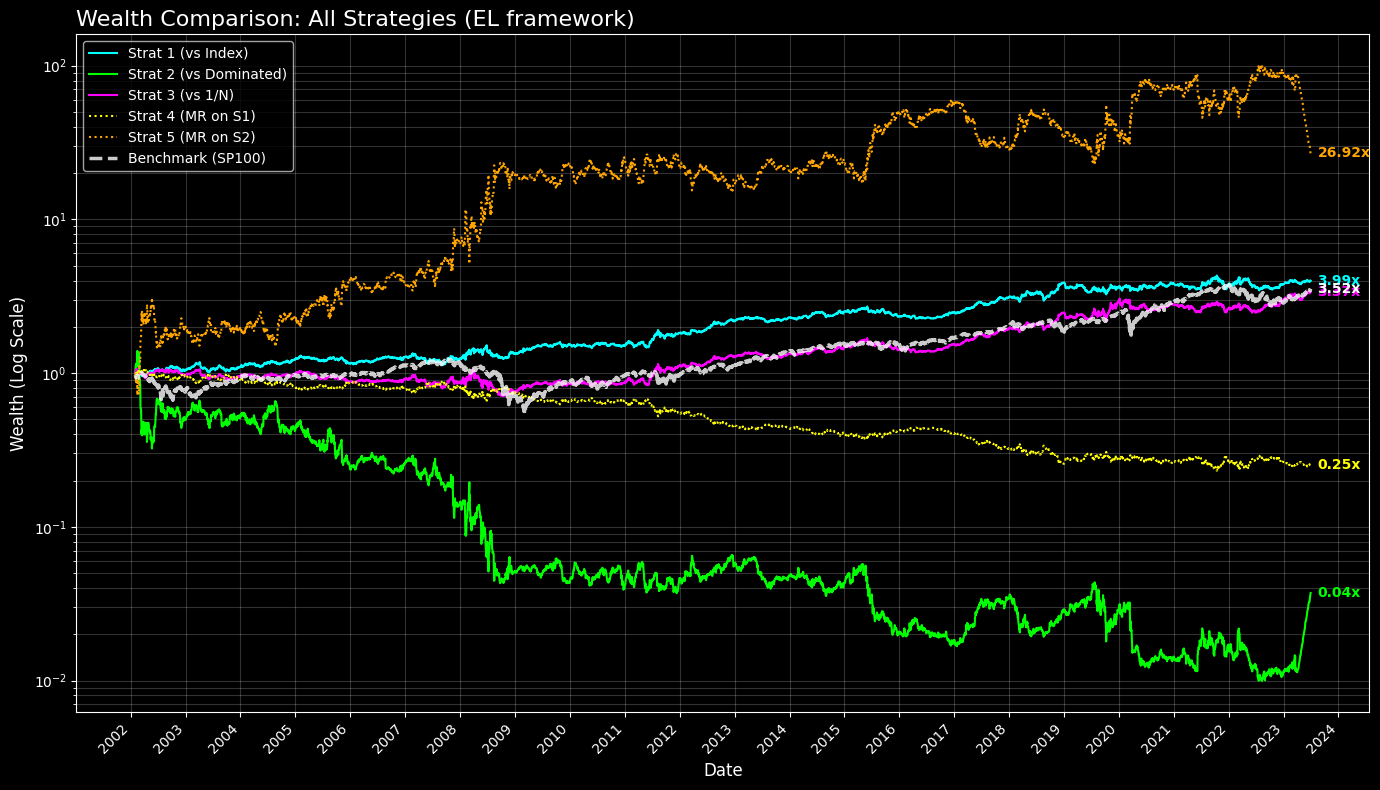

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

##############################
# plot all startegies
##############################
plt.figure(figsize=(14, 8))
plt.style.use('dark_background')

colors = ['cyan', 'lime', 'magenta', 'yellow', 'orange']
labels = ["Strat 1 (vs Index)", "Strat 2 (vs Dominated)", "Strat 3 (vs 1/N)",
          "Strat 4 (MR on S1)", "Strat 5 (MR on S2)"]
styles = ['-', '-', '-', ':', ':']

# Define initial wealth for plotting, assuming 1.0 based on W initialization
init_w = 1.0

# Get the dates for plotting, starting from when the wealth accumulation begins
plot_dates = returns.index[start_row_idx : tt+1]

# Plot all 5 strategies
for i in range(tot_strats):
    # Slice W_final to start from start_row_idx to avoid initial zeros
    plt.plot(plot_dates, W_final[start_row_idx:, i], label=labels[i], color=colors[i], linestyle=styles[i], linewidth=1.5)
    # Label Final Value
    final_val = W_final[-1, i]
    plt.annotate(f'{final_val:.2f}x', xy=(plot_dates[-1], final_val),
                 xytext=(5, 0), textcoords='offset points',
                 color=colors[i], fontweight='bold', va='center')

# Plot benchmark
bench_wealth = (1 + benchmark).cumprod()
bench_aligned = bench_wealth.reindex(returns.index[start_index:], method='ffill')
bench_aligned = bench_aligned / bench_aligned.iloc[0] * init_w

# Slice bench_aligned to start from start_row_idx to match wealth data
bench_aligned_for_plot = bench_aligned.iloc[start_row_idx : tt+1]

plt.plot(plot_dates, bench_aligned_for_plot.values, label='Benchmark (SP100)',
         color='white', linestyle='--', linewidth=2.5, alpha=0.8)
plt.annotate(f'{bench_aligned_for_plot.values[-1].item():.2f}x',
             xy=(plot_dates[-1], bench_aligned_for_plot.values[-1]),
             xytext=(5, 0), textcoords='offset points',
             color='white', fontweight='bold', va='center')

plt.title('Wealth Comparison: All Strategies (EL framework)', fontsize=16, loc='left')
plt.ylabel('Wealth (Log Scale)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.yscale('log')
plt.grid(True, which="both", alpha=0.2)
plt.legend(loc="upper left")

# Set x-axis major ticks to years and format labels to show only the year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right') # Rotate date labels for better visibility

plt.tight_layout()
plt.show()

In [ ]:
#################################
# plot only vs dominated and reverse
#################################
plt.figure(figsize=(14, 8))
plt.style.use('dark_background')

# Original labels and configurations (for reference, though not all used directly)
original_labels = ["Strat 1 (vs Index)", "Strat 2 (vs Dominated)", "Strat 3 (vs 1/N)",
                   "Strat 4 (MR on S1)", "Strat 5 (MR on S2)"]
original_colors = ['cyan', 'lime', 'magenta', 'yellow', 'orange']
original_styles = ['-', '-', '-', ':', ':']

# Select desired strategies: Strat 2 (index 1) and Strat 5 (index 4)
selected_indices = [1, 4]
selected_labels = [original_labels[i] for i in selected_indices]
selected_colors = [original_colors[i] for i in selected_indices]
selected_styles = [original_styles[i] for i in selected_indices]

# Define initial wealth for plotting, assuming 1.0 based on W initialization
init_w = 1.0

# Get the dates for plotting, starting from when the wealth accumulation begins
plot_dates = returns.index[start_row_idx : tt+1]

# Plot selected strategies
for i, original_idx in enumerate(selected_indices):
    plt.plot(plot_dates, W_final[start_row_idx:, original_idx], label=selected_labels[i], color=selected_colors[i], linestyle=selected_styles[i], linewidth=1.5)
    # Label Final Value
    final_val = W_final[-1, original_idx]
    plt.annotate(f'{final_val:.2f}x', xy=(plot_dates[-1], final_val),
                 xytext=(5, 0), textcoords='offset points',
                 color=selected_colors[i], fontweight='bold', va='center')

# Plot benchmark
bench_wealth = (1 + benchmark).cumprod()
bench_aligned = bench_wealth.reindex(returns.index[start_index:], method='ffill')
bench_aligned = bench_aligned / bench_aligned.iloc[0] * init_w

# Slice bench_aligned to start from start_row_idx to match wealth data
bench_aligned_for_plot = bench_aligned.iloc[start_row_idx : tt+1]

plt.plot(plot_dates, bench_aligned_for_plot.values, label='Benchmark (SP100)',
         color='white', linestyle='--', linewidth=2.5, alpha=0.8)
plt.annotate(f'{bench_aligned_for_plot.values[-1].item():.2f}x',
             xy=(plot_dates[-1], bench_aligned_for_plot.values[-1]),
             xytext=(5, 0), textcoords='offset points',
             color='white', fontweight='bold', va='center')

plt.title('Wealth Comparison: Strategy 1, Strategy 4, and Benchmark (EL framework)', fontsize=16, loc='left')
plt.ylabel('Wealth (Log Scale)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.yscale('log')
plt.grid(True, which="both", alpha=0.2)
plt.legend(loc="upper left")

# Set x-axis major ticks to years and format labels to show only the year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right') # Rotate date labels for better visibility

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
import pandas as pd


def calculate_metrics(wealth_series, periods_per_year=252, risk_free_rate=0.0):
    returns = wealth_series.pct_change().dropna()

    # Annualized Return & Volatility
    total_return = wealth_series.iloc[-1] / wealth_series.iloc[0] - 1
    annualized_return = (1 + total_return) ** (periods_per_year / len(returns)) - 1
    annualized_vol = returns.std() * np.sqrt(periods_per_year)

    # Sharpe Ratio
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol if annualized_vol != 0 else np.nan

    # Drawdown Calculations
    wealth_index = (1 + returns).cumprod()
    previous_peaks = wealth_index.cummax()
    drawdowns = (wealth_index - previous_peaks) / previous_peaks
    max_drawdown = drawdowns.min()

    # Calmar Ratio
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.nan

    # Sortino Ratio
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(periods_per_year)
    sortino_ratio = (annualized_return - risk_free_rate) / downside_vol if downside_vol != 0 else np.nan

    # Drawdown Duration
    in_drawdown = drawdowns < 0
    durations = []
    current_duration = 0
    for is_in_drawdown in in_drawdown:
        if is_in_drawdown:
            current_duration += 1
        else:
            if current_duration > 0:
                durations.append(current_duration)
            current_duration = 0
    if current_duration > 0:
        durations.append(current_duration)

    max_duration = max(durations) if durations else 0

    return {
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_vol,
        "Sharpe Ratio": sharpe_ratio,
        "Calmar Ratio": calmar_ratio,
        "Sortino Ratio": sortino_ratio,
        "Max Drawdown": max_drawdown,
        "Max Drawdown Duration (days)": max_duration
    }

# 1. Extract clean series, forcing 1D arrays to avoid dimensional errors
strat1_wealth = pd.Series(W_final[start_row_idx:, 0].flatten(), index=plot_dates, name='Strat 1')
benchmark_wealth = pd.Series(bench_aligned_for_plot.values.flatten(), index=plot_dates, name='Benchmark')

# 2. Calculate metrics
metrics_strat1 = calculate_metrics(strat1_wealth)
metrics_bench = calculate_metrics(benchmark_wealth)

# 3. Format into a clean DataFrame
metrics_df = pd.DataFrame([metrics_strat1, metrics_bench], index=['Strat 1', 'Benchmark']).T
display(metrics_df.round(4))

NameError: name 'W_final' is not defined